# 02. 슬롯 머신 환경 (Bandit Environment) 구현





In [7]:
import numpy as np
import matplotlib.pyplot as plt 

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 난수 생성기 시드 설정 (재현성 보장)
rng = np.random.default_rng(42)

# 문제의 정의

당신은 카지노의 슬롯머신 게임을 하고 있습니다:
- K개의 슬롯머신 중 하나를 선택
- 각 머신마다 당첨 확률이 다름 (하지만 정확한 확률은 모름)
- N번만 플레이 할 수 있음
- 목표: 총 보상을 최대화

### 수식으로 표현

**행동**: 선택한 슬롯 머신
$$A \in \{0, 1, 2, \ldots, K-1\}$$

**보상**: 이진(binary) 보상 
$$R\in \{0, 1\}$$

행동$a$를 선택했을 때 받을 보상 $R$의 기대값
$$q(a) = \mathbb{E}[R | A = a]$$

$q(a)$: 행동 $a$의 실제 행동 가치  

$\rightarrow$ 행동 $a$를 선택했을 때 받을 보상의 기댓값


### 예제 1: 10개 슬롯머신

| 슬롯 머신 번호 | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|--------|---|---|---|---|---|---|---|---|---|---|
| $q(a)$ | 0.37 | 0.20 | 0.09 | 0.65 | 0.46 | 0.99 | 0.85 | 0.84 | 0.05 | 0.56 |

**관찰**:
- 슬롯 머신 5가 최적 (당첨 확률 99%)
- 슬롯 머신 8이 최악 (당첨 확률 5%)
- 에이전트는 관찰을 통해 이를 찾아야 함



In [8]:
np.random.seed(22)  

K = 10 
true_rates = np.random.rand(K)  # 각 슬롯머신의 당첨 확률

print(f"K={K}개 슬롯머신의 당첨 확률:")
print(np.round(true_rates, 3))
print(f"\n최적 슬롯머신: 슬롯머신 {np.argmax(true_rates)} (확률={np.max(true_rates):.3f})")
print(f"최악 슬롯머신: 슬롯머신 {np.argmin(true_rates)} (확률={np.min(true_rates):.3f})")

K=10개 슬롯머신의 당첨 확률:
[0.208 0.482 0.421 0.859 0.171 0.339 0.271 0.691 0.22  0.812]

최적 슬롯머신: 슬롯머신 3 (확률=0.859)
최악 슬롯머신: 슬롯머신 4 (확률=0.171)


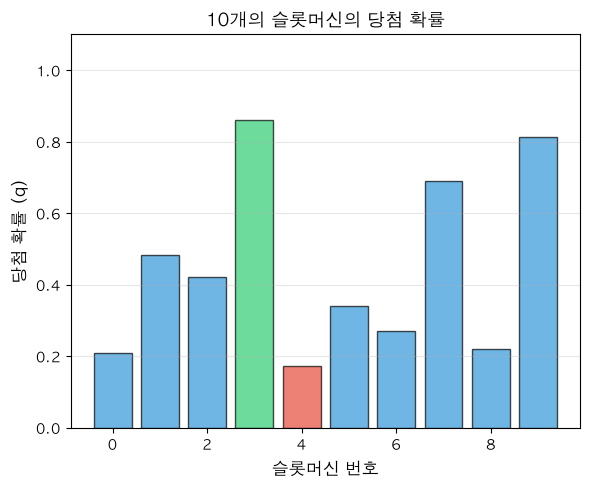

In [9]:
# 각 슬롯머신의 실제 당첨 확률 시각화
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# 왼쪽: 각 슬롯머신의 실제 확률
colors = ['#2ecc71' if i == np.argmax(true_rates) else '#e74c3c' if i == np.argmin(true_rates) else '#3498db' for i in range(K)]
bars = ax.bar(range(K), true_rates, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('슬롯머신 번호', fontsize=12, fontweight='bold')
ax.set_ylabel('당첨 확률 (q)', fontsize=12, fontweight='bold')
ax.set_title('10개의 슬롯머신의 당첨 확률', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

class Bandit:
    def __init__(self, arms=10, seed=22):
        self.rng = np.random.default_rng(seed)
        # 각 슬롯머신의 당첨 확률을 0~1 균등분포에서 샘플링
        self.rates = self.rng.random(arms)

    def play(self, arm):
        """
        주어진 슬롯머신을 플레이하고 보상을 반환
        """
        # 선택한 슬롯머신의 참 당첨 확률
        rate = self.rates[arm]
        # 무작위 추출값 < p이면 당첨
        if rate > self.rng.random():
            return 1 # 당첨
        else:
            return 0 # 실패

In [15]:
 # Bandit 인스턴스 생성
bandit = Bandit(arms=K, seed=42)

print("슬롯머신의 당첨 확률:")
print(np.round(bandit.rates, 3))



슬롯머신의 당첨 확률:
[0.774 0.439 0.859 0.697 0.094 0.976 0.761 0.786 0.128 0.45 ]



#### 확률론 기반 보상 생성

슬롯 머신 $a$를 선택했을 때의 **실제**행동 가치를 $p_a = q(a)$라 하면:

$$P(R = 1 | A = a) = p_a$$
$$P(R = 0 | A = a) = 1 - p_a$$


### 예제: 난수로 당첨 판정

**시나리오**: $p_a = 0.6$ (당첨 확률 60%)

| 시행 | 난수 $U$ | 비교 | 결과 |
|------|---------|------|------|
| 1 | 0.25 | 0.25 < 0.6 ✓ | **당첨** (R=1) |
| 2 | 0.72 | 0.72 < 0.6 ✗ | **실패** (R=0) |
| 3 | 0.45 | 0.45 < 0.6 ✓ | **당첨** (R=1) |
| 4 | 0.83 | 0.83 < 0.6 ✗ | **실패** (R=0) |
| 5 | 0.15 | 0.15 < 0.6 ✓ | **당첨** (R=1) |

### 큰 수의 법칙 (Law of Large Numbers)

같은 슬롯 머신 $a$를 독립적으로 $n$번 플레이하여 표본평균을 구한다. 단. 그동안 기기의 당첨 확률은 변하지 않는다.
$$\hat{p}_{a,n} = \frac{1}{n}\sum_{i=1}^{n} R_i^{(a)}\xrightarrow{P} p_a$$
시행 횟수 $n$이 증가할수록 표본평균은 실제 당첨 확률 $p_a$에 확률적으로 수렴합니다.


In [16]:

# 각 슬롯머신을 여러 번 플레이하여 관측된 보상으로부터 표본 평균을 계산

N_trials = 10000  # 각 슬롯머신의 플레이 횟수
observed_rates = []  # 플레이하여  관측된 당첨 확률

for arm in range(K):
    rewards = []
    for _ in range(N_trials):
        reward = bandit.play(arm)
        rewards.append(reward)
    
    observed_rate = np.mean(rewards)
    observed_rates.append(observed_rate)
    
    error = abs(observed_rate - bandit.rates[arm])
    print(f"슬롯머신 {arm}: 실제 ={bandit.rates[arm]:.3f}, 관측={observed_rate:.3f}, 오차={error:.3f}")

observed_rates = np.array(observed_rates)

슬롯머신 0: 실제 =0.774, 관측=0.779, 오차=0.005
슬롯머신 1: 실제 =0.439, 관측=0.437, 오차=0.002
슬롯머신 2: 실제 =0.859, 관측=0.861, 오차=0.003
슬롯머신 3: 실제 =0.697, 관측=0.693, 오차=0.004
슬롯머신 4: 실제 =0.094, 관측=0.094, 오차=0.000
슬롯머신 5: 실제 =0.976, 관측=0.977, 오차=0.001
슬롯머신 6: 실제 =0.761, 관측=0.761, 오차=0.000
슬롯머신 7: 실제 =0.786, 관측=0.784, 오차=0.002
슬롯머신 8: 실제 =0.128, 관측=0.129, 오차=0.001
슬롯머신 9: 실제 =0.450, 관측=0.453, 오차=0.003
